#### 1142_DS_Lab5 資料合併與時間序列資料視覺化呈現

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#在Jupyter Notebook上顯示圖表所必需的　magic command,
%matplotlib inline

# 整體目標：選取國泰北美科技與台積電的收盤價並繪製趨勢圖

# 工具：concat，merge，空值處理


##  一、爬取資料


##  目標：使用迴圈爬取365天的股市資料，並銜接在一起。
## pd.concat()  
將兩個DataFrame依照自己的條件連接在一起

In [2]:
data_a = pd.DataFrame([[0, 1, 2], [3, 4, 5], [6, 7, 8]],columns = ['key','A','B'])
data_b = pd.DataFrame([[0, 1, 0], [3, 1, 0], [6, 0, 1],[9, 1, 2]],columns = ['key','A','B'])
data_c = pd.DataFrame([[0, 1], [3, 4], [6, 7]],columns = ['key','A'])

In [3]:
display(data_a)
display(data_b)
display(data_c)

,key,A,B
0,0,1,2
1,3,4,5
2,6,7,8


,key,A,B
0,0,1,0
1,3,1,0
2,6,0,1
3,9,1,2


,key,A
0,0,1
1,3,4
2,6,7


In [4]:
# concat 使用 join 設定
# join 有兩種模式，分別為 inner, outer
# result = pd.concat([data_a,data_b])             # 預設 axis=0
#  concat 預設的 join 模式是 'outer'，會直接把沒有的資料用 NaN 代替
#  concat 的 join 模式為 'inner'，會直接把沒有完整資料的刪除

result = pd.concat([data_a,data_b], join='outer')   

print(result)

   key  A  B
0    0  1  2
1    3  4  5
2    6  7  8
0    0  1  0
1    3  1  0
2    6  0  1
3    9  1  2


In [5]:
result = pd.concat([data_a,data_c], join='outer')
print(result)

   key  A    B
0    0  1  2.0
1    3  4  5.0
2    6  7  8.0
0    0  1  NaN
1    3  4  NaN
2    6  7  NaN


In [6]:
result = pd.concat([data_a,data_c], join='inner')
print(result)

   key  A
0    0  1
1    3  4
2    6  7
0    0  1
1    3  4
2    6  7


In [7]:
result = pd.concat([data_a,data_b], join='inner', ignore_index=True)
# ignore_index = True 可以忽略合併時舊的 index 欄位，改採用自動產生的 index
print(result)

   key  A  B
0    0  1  2
1    3  4  5
2    6  7  8
3    0  1  0
4    3  1  0
5    6  0  1
6    9  1  2


In [8]:
#垂直併接　　(keys構建分層索引使用通過的鍵作為最外面的級別)
pd.concat([data_a,data_b],keys=['x','y'])

key  A  B
x 0    0  1  2
  1    3  4  5
  2    6  7  8
y 0    0  1  0
  1    3  1  0
  2    6  0  1
  3    9  1  2

In [12]:
#橫向併接
pd.concat([data_a,data_b],keys=['x','y'],axis = 1)

x             y      
   key    A    B key  A  B
0  0.0  1.0  2.0   0  1  0
1  3.0  4.0  5.0   3  1  0
2  6.0  7.0  8.0   6  0  1
3  NaN  NaN  NaN   9  1  2

## 實例：

## Notes : 如果同時爬取過多資料，伺服器會誤以為是網路攻擊而將該IP封鎖至少一天，所以建議使用 time套件裡的 time.sleep()來延遲抓取 ，請同學實作時避免同時間大量下載資料。

In [2]:
import requests
import time
import datetime

In [5]:
data = pd.DataFrame()

In [6]:
first_date = datetime.date(2026,1,1)
print(first_date)
date = str(first_date).replace('-','') 
print (date)

2026-01-01
20260101


# Bug 説明


## 原先迴圈邏輯：for i in range(0,10,1):

### 🔍 問題分析：

- 這段使用 `for i in range(0, 10, 1)` 搭配 `first_date += datetime.timedelta(days=1)`。
- 雖然表面看起來跑了 10 天，但如果你 **多次執行這個 cell**，每次都會再 `concat` 10 天資料，**不會清空 `data`**，會導致重複寫入相同日期的資料。
- ❌ 沒有 `drop_duplicates()` 的機制來移除重複。


In [7]:
# 設定起始日期
first_date = datetime.date(2026, 1, 2)

# 要抓幾天的資料（這裡是 10 天）
days_to_fetch = 10
        
for i in range(days_to_fetch):
    print(f"正在抓取資料：{first_date}")

    # 將日期轉為字串格式（yyyyMMdd）用於 API
    date = first_date.strftime("%Y%m%d")
    url = f"https://www.twse.com.tw/exchangeReport/MI_INDEX?response=json&date={date}&type=ALLBUT0999"

    try:
        response = requests.get(url)
        response_json = response.json()

        # 檢查是否有資料可用
        if response_json.get("stat") != "OK" or "tables" not in response_json:
            print(f"⚠️ {first_date} 無資料，跳過")
            first_date += datetime.timedelta(days=1)
            continue

        # 抓取每日收盤行情
        stock_data = []
        stock_fields = []
        for table in response_json["tables"]:
            if "每日收盤行情" in table["title"]:
                stock_data = table["data"]
                stock_fields = table["fields"]
                break

        # 若有抓到資料
        if stock_data:
            stock = pd.DataFrame(stock_data, columns=stock_fields)
            stock["date"] = first_date

            # 合併並去除重複（依據：日期＋證券代號）
            data = pd.concat([data, stock], ignore_index=True)
            data.drop_duplicates(subset=["date", "證券代號"], keep="last", inplace=True)

            print(f"{first_date} 資料已加入")
        else:
            print(f"⚠️ {first_date} 找不到收盤行情資料")

    except Exception as e:
        print(f"發生錯誤：{e}")

    # 日期往後一天
    first_date += datetime.timedelta(days=1)

    # 避免過載 API
    time.sleep(5)

正在抓取資料：2026-01-02
2026-01-02 資料已加入
正在抓取資料：2026-01-03
⚠️ 2026-01-03 無資料，跳過
正在抓取資料：2026-01-04
⚠️ 2026-01-04 無資料，跳過
正在抓取資料：2026-01-05
2026-01-05 資料已加入
正在抓取資料：2026-01-06
2026-01-06 資料已加入
正在抓取資料：2026-01-07
2026-01-07 資料已加入
正在抓取資料：2026-01-08
2026-01-08 資料已加入
正在抓取資料：2026-01-09
2026-01-09 資料已加入
正在抓取資料：2026-01-10
⚠️ 2026-01-10 無資料，跳過
正在抓取資料：2026-01-11
⚠️ 2026-01-11 無資料，跳過


In [8]:
print(data)

      證券代號      證券名稱        成交股數    成交筆數           成交金額     開盤價     最高價  \
0     0050    元大台灣50  81,135,717  69,896  5,396,295,605   66.00   67.00   
1     0051   元大中型100      95,494     334      8,813,748   91.50   92.75   
2     0052      富邦科技  46,573,974  19,613  1,789,438,944   38.09   38.78   
3     0053      元大電子      34,000     199      4,865,997  142.30  144.20   
4     0055  元大MSCI金融     267,162     441      8,516,670   31.95   32.00   
...    ...       ...         ...     ...            ...     ...     ...   
7992  9944        新麗      19,950      46        336,738   16.90   16.95   
7993  9945       潤泰新   5,347,718   2,718    156,518,077   29.40   29.60   
7994  9946      三發地產     233,060     151      4,441,007   19.50   19.50   
7995  9955        佳龍     375,288     328     11,422,245   30.50   30.70   
7996  9958       世紀鋼   1,092,471   1,414    145,706,434  136.00  136.00   

         最低價     收盤價                      漲跌(+/-)  漲跌價差  最後揭示買價 最後揭示買量  \
0      65.80   66.95    <

In [9]:
#請爬取完後進行輸出保存，以免未來需要從重新使用原始資料
# data.to_csv('../data_science_data.csv')
data.to_csv("data_science_data_cleaned.csv", index=False)

In [10]:
pwd

'/home/yfhd/Documents/114-2/Data Science/lab5'

In [11]:
#請用絕對位置，相對路徑會導向安裝anaconda的地方
data = pd.read_csv('data_science_data_cleaned.csv',index_col=0)

In [12]:
data

,證券名稱,成交股數,成交筆數,成交金額,開盤價,最高價,最低價,收盤價,漲跌(+/-),漲跌價差,最後揭示買價,最後揭示買量,最後揭示賣價,最後揭示賣量,本益比,date
證券代號,,,,,,,,,,,,,,,,
0050,元大台灣50,"81,135,717","69,896","5,396,295,605",66.00,67.00,65.80,66.95,<p style= color:red>+</p>,1.35,66.90,"1,203",66.95,372,0.00,2026-01-02
0051,元大中型100,"95,494",334,"8,813,748",91.50,92.75,91.50,92.35,<p style= color:red>+</p>,0.85,92.15,1,92.35,1,0.00,2026-01-02
0052,富邦科技,"46,573,974","19,613","1,789,438,944",38.09,38.78,37.94,38.76,<p style= color:red>+</p>,0.87,38.75,157,38.76,548,0.00,2026-01-02
0053,元大電子,"34,000",199,"4,865,997",142.30,144.20,142.30,143.65,<p style= color:red>+</p>,2.75,140.20,1,143.80,1,0.00,2026-01-02
0055,元大MSCI金融,"267,162",441,"8,516,670",31.95,32.00,31.72,31.95,<p> </p>,0.00,31.92,2,31.95,1,0.00,2026-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,新麗,"19,950",46,"336,738",16.90,16.95,16.70,16.95,<p style= color:red>+</p>,0.05,16.70,4,16.95,4,0.00,2026-01-09
9945,潤泰新,"5,347,718","2,718","156,518,077",29.40,29.60,29.15,29.35,<p style= color:red>+</p>,0.05,29.30,57,29.35,93,8.87,2026-01-09
9946,三發地產,"233,060",151,"4,441,007",19.50,19.50,18.95,19.05,<p style= color:green>-</p>,0.10,19.00,23,19.05,2,105.83,2026-01-09


# 二、資料清理

## 目標：整理出一個DataFrame 包含日期、國泰北美科技收盤價、台積電收盤價

In [19]:
#只取出想要的columns
data = data[['date','證券名稱','收盤價']]

In [20]:
data

,date,證券名稱,收盤價
證券代號,,,
0050,2026-01-08,元大台灣50,70.10
0051,2026-01-08,元大中型100,95.45
0052,2026-01-08,富邦科技,40.84
0053,2026-01-08,元大電子,150.00
0055,2026-01-08,元大MSCI金融,31.99
...,...,...,...
9944,2026-01-09,新麗,16.95
9945,2026-01-09,潤泰新,29.35
9946,2026-01-09,三發地產,19.05


In [21]:
#把收盤價改為英文標題，未來處理其他程序時才不會有警告圖示
data = data.rename(columns = {'證券名稱':'name'})
data = data.rename(columns = {'收盤價':'closing_price'})

In [22]:
data.describe()  # 目前資料都是字串

,date,name,closing_price
count,9331,9331,9331
unique,7,1335,3064
top,2026-01-08,世紀鋼,--
freq,1334,7,69


### 轉換收盤價的資料型態(object -> float)，詳情請參考lab3。轉換目的：未來在繪圖時float型態才可運行

In [23]:
data['closing_price'] = data['closing_price'].replace({'\$':'', ',':'', '--':np.nan}, regex=True)
data['closing_price'] = data['closing_price'].astype('float64')

In [24]:
data.describe()

,closing_price
count,9262.000000
mean,99.612834
std,294.549384
min,0.810000
25%,18.350000
50%,37.000000
75%,77.675000
max,4670.000000


## merge()
將兩個DataFrame依照設定的key組合在一起.

In [25]:
data_a = pd.DataFrame([[0, 1, 2], [3, 4, 5], [6, 7, 8]],columns = ['key','A','B'])
data_b = pd.DataFrame([[0, 1, 0], [3, 1, 0], [6, 0, 1],[9, 1, 2]],columns = ['key','A','B'])

In [26]:
display(data_a)
display(data_b)

,key,A,B
0,0,1,2
1,3,4,5
2,6,7,8


,key,A,B
0,0,1,0
1,3,1,0
2,6,0,1
3,9,1,2


### on參數：依照設定參數當作key進行合併

### how參數：有left(依照輸入左側的df進行合併)、right(右側)、inner(取交集)、outer(取聯集)

In [27]:
pd.merge(data_a,data_b,on='key',how='left')

,key,A_x,B_x,A_y,B_y
0,0,1,2,1,0
1,3,4,5,1,0
2,6,7,8,0,1


#### suffixes參數：更改後綴名稱

In [28]:
pd.merge(data_a,data_b,on='key',how='left', suffixes=('_a', '_b'))

,key,A_a,B_a,A_b,B_b
0,0,1,2,1,0
1,3,4,5,1,0
2,6,7,8,0,1


## 實例：

## 把國泰北美科技的資料與台積電的資料進行合併

In [29]:
data_ETF = data[data['name']=='國泰北美科技']

In [30]:
data_TSMC = data[data['name']=='台積電']

In [31]:
display(data_ETF)
display(data_TSMC)

,date,name,closing_price
證券代號,,,
00770,2026-01-08,國泰北美科技,58.75
00770,2026-01-12,國泰北美科技,58.35
00770,2026-01-02,國泰北美科技,58.10
00770,2026-01-05,國泰北美科技,57.95
00770,2026-01-06,國泰北美科技,58.20
00770,2026-01-07,國泰北美科技,58.65
00770,2026-01-09,國泰北美科技,58.35


,date,name,closing_price
證券代號,,,
2330,2026-01-08,台積電,1685.0
2330,2026-01-12,台積電,1690.0
2330,2026-01-02,台積電,1585.0
2330,2026-01-05,台積電,1670.0
2330,2026-01-06,台積電,1705.0
2330,2026-01-07,台積電,1675.0
2330,2026-01-09,台積電,1680.0


In [ ]:
# 以後不須使用的證券名稱，所以先行丟掉
data_ETF = data_ETF.drop('name',axis = 1)
data_TSMC = data_TSMC.drop('name',axis = 1)

In [ ]:
display(data_ETF)
display(data_TSMC)

,date,closing_price
證券代號,,
00770,2024-01-03,38.67
00770,2024-01-04,38.47
00770,2024-01-05,38.22
00770,2024-01-08,38.24
00770,2024-01-09,39.19
00770,2024-01-10,39.47
00770,2024-01-11,40.05
00770,2024-01-12,40.03


,date,closing_price
證券代號,,
2330,2024-01-03,578.0
2330,2024-01-04,580.0
2330,2024-01-05,576.0
2330,2024-01-08,583.0
2330,2024-01-09,586.0
2330,2024-01-10,584.0
2330,2024-01-11,586.0
2330,2024-01-12,584.0


In [32]:
data = pd.merge(data_ETF,data_TSMC,on='date',how = 'left',suffixes=('_ETF','_TSMC'))

In [33]:
data

,date,name_ETF,closing_price_ETF,name_TSMC,closing_price_TSMC
0,2026-01-08,國泰北美科技,58.75,台積電,1685.0
1,2026-01-12,國泰北美科技,58.35,台積電,1690.0
2,2026-01-02,國泰北美科技,58.10,台積電,1585.0
3,2026-01-05,國泰北美科技,57.95,台積電,1670.0
4,2026-01-06,國泰北美科技,58.20,台積電,1705.0
5,2026-01-07,國泰北美科技,58.65,台積電,1675.0
6,2026-01-09,國泰北美科技,58.35,台積電,1680.0


In [ ]:
data.describe()

,closing_price_ETF,closing_price_TSMC
count,8.000000,8.000000
mean,39.042500,582.125000
std,0.754203,3.720119
min,38.220000,576.000000
25%,38.412500,579.500000
50%,38.930000,583.500000
75%,39.610000,584.500000
max,40.050000,586.000000


# 空值處理

## 範例

In [34]:
data_a = pd.DataFrame([[0, 1, 2], [3, 4, 5], [11, 7, 8]],columns = ['key','A','B'])
data_b = pd.DataFrame([[0, 1, 0], [2, 1, 0], [6, 0, 1],[9, 1, 2]],columns = ['key','A','B'])

In [35]:
print(data_a)
print(data_b)

   key  A  B
0    0  1  2
1    3  4  5
2   11  7  8
   key  A  B
0    0  1  0
1    2  1  0
2    6  0  1
3    9  1  2


In [36]:
data_test = pd.merge(data_a,data_b,on='key',how = 'outer')
data_test

,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0
1,2,NaN,NaN,1.0,0.0
2,3,4.0,5.0,NaN,NaN
3,6,NaN,NaN,0.0,1.0
4,9,NaN,NaN,1.0,2.0
5,11,7.0,8.0,NaN,NaN


## dropna 將有空值的row刪除

In [37]:
data_test.dropna()

,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0


In [38]:
data_test.dropna(axis='columns')

,key
0,0
1,2
2,3
3,6
4,9
5,11


In [39]:
data_test.dropna(axis='columns', how='all')

,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0
1,2,NaN,NaN,1.0,0.0
2,3,4.0,5.0,NaN,NaN
3,6,NaN,NaN,0.0,1.0
4,9,NaN,NaN,1.0,2.0
5,11,7.0,8.0,NaN,NaN


In [ ]:
data_test.dropna(axis='rows', thresh=4)

,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0


## fillna 將有空值的地方填上想要的值

In [40]:
data_test.fillna(0)

,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0
1,2,0.0,0.0,1.0,0.0
2,3,4.0,5.0,0.0,0.0
3,6,0.0,0.0,0.0,1.0
4,9,0.0,0.0,1.0,2.0
5,11,7.0,8.0,0.0,0.0


In [41]:
data_test.fillna(method='ffill')

C:\Users\twp\AppData\Local\Temp\ipykernel_8668\4186204044.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_test.fillna(method='ffill')


,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0
1,2,1.0,2.0,1.0,0.0
2,3,4.0,5.0,1.0,0.0
3,6,4.0,5.0,0.0,1.0
4,9,4.0,5.0,1.0,2.0
5,11,7.0,8.0,1.0,2.0


In [42]:
data_test.fillna(method='bfill')

C:\Users\twp\AppData\Local\Temp\ipykernel_8668\2109803955.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_test.fillna(method='bfill')


,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0
1,2,4.0,5.0,1.0,0.0
2,3,4.0,5.0,0.0,1.0
3,6,7.0,8.0,0.0,1.0
4,9,7.0,8.0,1.0,2.0
5,11,7.0,8.0,NaN,NaN


## pd.isnull()  pd.notnull() 產生是否為空值的布林Series

In [43]:
pd.isnull(data_test['A_x'])

0    False
1     True
2    False
3     True
4     True
5    False
Name: A_x, dtype: bool

In [44]:
data_test[pd.isnull(data_test['A_x'])]

,key,A_x,B_x,A_y,B_y
1,2,NaN,NaN,1.0,0.0
3,6,NaN,NaN,0.0,1.0
4,9,NaN,NaN,1.0,2.0


In [45]:
pd.notnull(data_test['A_x'])

0     True
1    False
2     True
3    False
4    False
5     True
Name: A_x, dtype: bool

In [46]:
data_test[pd.notnull(data_test['A_x'])]

,key,A_x,B_x,A_y,B_y
0,0,1.0,2.0,1.0,0.0
2,3,4.0,5.0,NaN,NaN
5,11,7.0,8.0,NaN,NaN


#### 實例：

## 有些股票可能沒有交易資訊，必須清除乾淨

In [47]:
data[pd.isnull(data['closing_price_ETF'])]

,date,name_ETF,closing_price_ETF,name_TSMC,closing_price_TSMC


In [48]:
data = data.dropna()

# 三、簡易顯示圖表

## pd.plot()  附註：plot未來會詳細解釋

In [49]:
#df內的資料型態必須一樣，所以使日期當作是index也就是橫坐標
data = data.set_index('date')

In [50]:
data

,name_ETF,closing_price_ETF,name_TSMC,closing_price_TSMC
date,,,,
2026-01-08,國泰北美科技,58.75,台積電,1685.0
2026-01-12,國泰北美科技,58.35,台積電,1690.0
2026-01-02,國泰北美科技,58.10,台積電,1585.0
2026-01-05,國泰北美科技,57.95,台積電,1670.0
2026-01-06,國泰北美科技,58.20,台積電,1705.0
2026-01-07,國泰北美科技,58.65,台積電,1675.0
2026-01-09,國泰北美科技,58.35,台積電,1680.0


In [51]:
display(data_ETF)
display(data_TSMC)

,date,name,closing_price
證券代號,,,
00770,2026-01-08,國泰北美科技,58.75
00770,2026-01-12,國泰北美科技,58.35
00770,2026-01-02,國泰北美科技,58.10
00770,2026-01-05,國泰北美科技,57.95
00770,2026-01-06,國泰北美科技,58.20
00770,2026-01-07,國泰北美科技,58.65
00770,2026-01-09,國泰北美科技,58.35


,date,name,closing_price
證券代號,,,
2330,2026-01-08,台積電,1685.0
2330,2026-01-12,台積電,1690.0
2330,2026-01-02,台積電,1585.0
2330,2026-01-05,台積電,1670.0
2330,2026-01-06,台積電,1705.0
2330,2026-01-07,台積電,1675.0
2330,2026-01-09,台積電,1680.0


<AxesSubplot:xlabel='date'>

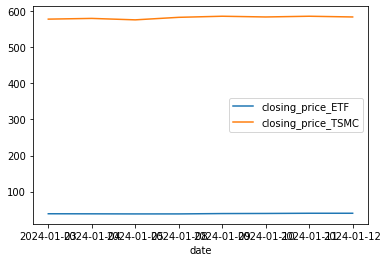

In [ ]:
#如果按一次沒顯示，那就再按一次。
data.plot()

# 抓取2025整年份台股資料

In [2]:
import pandas as pd
import requests
import time
import datetime
import os

# 初始化 DataFrame
data = pd.DataFrame()

# 設定起始日期與結束日期
start_date = datetime.date(2025, 1, 1)
end_date = datetime.date(2025, 12, 31)

# 迴圈遍歷每一天
first_date = start_date

while first_date <= end_date:
    print(f"Fetching data for {first_date}...")

    # 轉換日期格式為 YYYYMMDD (適合 API 使用)
    date_str = first_date.strftime('%Y%m%d')

    # API 網址
    url = f'https://www.twse.com.tw/exchangeReport/MI_INDEX?response=json&date={date_str}&type=ALLBUT0999'
    
    try:
        # 發送請求
        response = requests.get(url)
        response_json = response.json()
        
        # 確保 API 回應成功
        if response_json.get('stat') != 'OK' or 'tables' not in response_json:
            print(f"⚠ No data for {first_date}, skipping...")
            first_date += datetime.timedelta(days=1)
            continue  # 跳過當天，繼續下一天

        # 解析數據
        stock_data = []
        stock_fields = []
        for table in response_json['tables']:
            if "每日收盤行情" in table['title']:
                stock_data = table['data']
                stock_fields = table['fields']
                break

        # 將數據轉換為 DataFrame
        if stock_data:
            stock = pd.DataFrame(stock_data, columns=stock_fields)
            stock['date'] = first_date  # 記錄日期
            
            # 合併數據，確保不會有重複的日期
            data = pd.concat([data, stock])
            data.drop_duplicates(subset=['date', '證券代號'], keep='last', inplace=True)
            data.reset_index(drop=True, inplace=True)

            print(f"✅ Data for {first_date} added.")
        else:
            print(f"⚠ No stock data available for {first_date}, skipping...")

    except Exception as e:
        print(f"❌ Error on {first_date}: {e}")

    # 增加一天
    first_date += datetime.timedelta(days=1)

    # **延遲 5 秒，避免過載 API**
    time.sleep(1)

Fetching data for 2025-01-01...
⚠ No data for 2025-01-01, skipping...
Fetching data for 2025-01-02...
✅ Data for 2025-01-02 added.
Fetching data for 2025-01-03...
✅ Data for 2025-01-03 added.
Fetching data for 2025-01-04...
⚠ No data for 2025-01-04, skipping...
Fetching data for 2025-01-05...
⚠ No data for 2025-01-05, skipping...
Fetching data for 2025-01-06...
✅ Data for 2025-01-06 added.
Fetching data for 2025-01-07...
✅ Data for 2025-01-07 added.
Fetching data for 2025-01-08...
✅ Data for 2025-01-08 added.
Fetching data for 2025-01-09...
✅ Data for 2025-01-09 added.
Fetching data for 2025-01-10...
✅ Data for 2025-01-10 added.
Fetching data for 2025-01-11...
⚠ No data for 2025-01-11, skipping...
Fetching data for 2025-01-12...
⚠ No data for 2025-01-12, skipping...
Fetching data for 2025-01-13...
✅ Data for 2025-01-13 added.
Fetching data for 2025-01-14...
✅ Data for 2025-01-14 added.
Fetching data for 2025-01-15...
✅ Data for 2025-01-15 added.
Fetching data for 2025-01-16...
✅ Data f

In [3]:
# 存成 CSV
data.to_csv('data_science_data2025.csv')

##### 作業三 (Due 2026/0408) 題目一: 請繪製台積電在2025年的收盤價及開盤價的趨勢圖。